In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm
from sklearn.cluster import DBSCAN, OPTICS
import pandas as pd
import scipy
import xarray as xr
import datetime
import time
from utils import *
from glob import glob
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

In [2]:
good_data_slices = [
        {
            'video_stamp': '20211028T140100Z',
            'times': [(2000,3000)],
            'missions': [66, 67],
        },
        {
            'video_stamp': '20211013T170100Z',
            'times': [(0, 275)],
            'missions': [32],
        },
        {
            'video_stamp': '20211013T163100Z',
            
            'times': [(0, 120)] ,
            'missions': [31],
        },
        {
            'video_stamp': '20211028T170100Z',
            'times': [(2900, 3050)],
            'missions': [69],
        },
        {
            'video_stamp': '20211026T160100Z',
            'times': [(2600, 3000)],
            'missions': [59],
        },
]

In [7]:
stamp = good_data_slices[0]['video_stamp']
missions = good_data_slices[0]['missions']
start, end = good_data_slices[0]['times'][0]

In [8]:
video_fname = glob(f'../../data/argus/*{stamp}*')[0]
video_metadata = glob(f'../../data/argus//metadata/*{stamp}*')[0]
import pickle
metadata = pickle.load(open(video_metadata, 'rb'))

In [9]:
frames = load_frames(video_fname)
ds = argus_sequence_to_xarray(frames, times=metadata['time'])

3.072gb allocated


Building Timestack:   0%|          | 0/3840 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 3840/3840 [00:04<00:00, 902.69it/s]


In [81]:
mission_ds = None
for mission in missions:
    mission_fname = glob(f'../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission}.nc')[0]
    mds = xr.load_dataset(mission_fname)
    print(mds.trajectory)
    if mission_ds is None:
        mission_ds = mds
    else:
        mission_ds.merge(mds)


<xarray.DataArray 'trajectory' (trajectory: 17)> Size: 68B
array([24, 23, 12, 30, 37, 62, 19, 21, 16, 45, 73, 60, 34, 66, 59, 50, 35],
      dtype=int32)
Coordinates:
  * trajectory  (trajectory) int32 68B 24 23 12 30 37 62 ... 60 34 66 59 50 35
Attributes:
    cf_role:      trajectory_id
    long_name:    trajectory name
    description:  microSWIFT drift track ID. The ID number is the same as the...
<xarray.DataArray 'trajectory' (trajectory: 22)> Size: 88B
array([48, 24, 23, 12,  3, 37, 64, 38, 62, 10, 21, 72, 16, 29, 45, 73, 60, 34,
       61, 59, 50, 35], dtype=int32)
Coordinates:
  * trajectory  (trajectory) int32 88B 48 24 23 12 3 37 64 ... 60 34 61 59 50 35
Attributes:
    cf_role:      trajectory_id
    long_name:    trajectory name
    description:  microSWIFT drift track ID. The ID number is the same as the...


In [82]:
def interpolate_mission_ds(mission_ds, ds):
    # Create a new dataset with the same structure as mission_ds
    interpolated_ds = xr.Dataset()
    
    # Interpolate each variable in mission_ds onto the time axis of ds
    for var in mission_ds.data_vars:
        if 'time' in mission_ds[var].dims:
            # Check if the variable has a time dimension
            interpolated_var = mission_ds[var].interp(time=ds.time, method='linear')
            
            # Handle NaN values that may occur due to extrapolation
            interpolated_var = interpolated_var.where(
                (ds.time >= mission_ds.time.min()) & (ds.time <= mission_ds.time.max())
            )
            
            interpolated_ds[var] = interpolated_var
        else:
            # If the variable doesn't have a time dimension, just copy it
            interpolated_ds[var] = mission_ds[var]
    
    # Copy attributes
    interpolated_ds.attrs = mission_ds.attrs
    
    return interpolated_ds

# Use the function
interpolated_mission_ds = interpolate_mission_ds(mission_ds, ds)


In [83]:
plt.figure(figsize=(20, 5))
i=0
for i in tqdm(range(start, end, 10)):
    ds.isel(time=i).T.plot(cmap='gray', vmin=0, vmax=255)
    mission_ds.isel(time=i).plot.scatter(x='xFRF', y='yFRF', marker='.', c='r', edgecolors='none')
    plt.gca().set_aspect(1)
    plt.savefig(f'../figures/swift_and_argus/{i:05d}.png')
    plt.clf()
    
! ffmpeg -framerate 20 -pattern_type glob -i '../figures/swift_and_argus/*.png' -c:v libx264 -pix_fmt yuv420p ../figures/swift_and_argus/output.mp4 -y

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:42<00:00,  2.36it/s]

ffmpeg version 7.0.2 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0.2_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex 

[out#0/mp4 @ 0x151e2cf70] video:4356KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.047550%
frame=  100 fps=0.0 q=-1.0 Lsize=    4358KiB time=00:00:04.90 bitrate=7286.0kbits/s speed=6.99x    
[libx264 @ 0x151e2ddd0] frame I:1     Avg QP:23.14  size: 68725
[libx264 @ 0x151e2ddd0] frame P:25    Avg QP:26.08  size: 47657
[libx264 @ 0x151e2ddd0] frame B:74    Avg QP:27.71  size: 43239
[libx264 @ 0x151e2ddd0] consecutive B-frames:  1.0%  0.0%  3.0% 96.0%
[libx264 @ 0x151e2ddd0] mb I  I16..4: 14.4% 71.7% 13.9%
[libx264 @ 0x151e2ddd0] mb P  I16..4:  0.5% 17.8% 10.9%  P16..4:  9.3%  4.5%  2.6%  0.0%  0.0%    skip:54.3%
[libx264 @ 0x151e2ddd0] mb B  I16..4:  0.3% 12.9%  9.5%  B16..8:  9.5%  5.5%  2.2%  direct: 2.0%  skip:58.1%  L0:48.9% L1:42.5% BI: 8.6%
[libx264 @ 0x151e2ddd0] 8x8 transform intra:58.6% inter:52.5%
[libx264 @ 0x151e2ddd0] coded y,uvDC,uvAC intra: 92.7% 0.2% 0.2% inter: 14.9% 0.2% 0.2%
[libx264 @ 0x151e2ddd0] i16 v,h,dc,p: 25% 36% 13% 26%
[

<Figure size 2000x500 with 0 Axes>

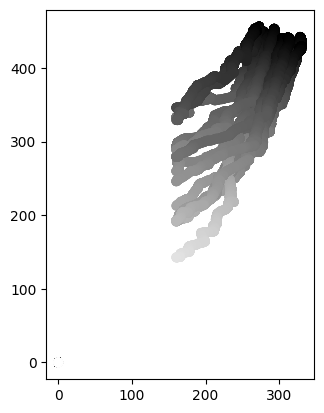

In [84]:
for i in range(len(mission_ds.trajectory)):
    traj = mission_ds.fillna(0).isel(trajectory=i)
    if traj.xFRF.max() < 1e3:
    # plt.hist(traj.xFRF)
        plt.scatter(traj.xFRF, traj.yFRF, c=traj.time, vmin=mission_ds.time.min(), vmax=mission_ds.time.max())
plt.gca().set_aspect(1)